In [ ]:
import requests
import pandas as pd

def get_orthologs_table(url, gene_id):
    json =  {
                "primaryKey": [
                    {"name": "source_id", "value": gene_id},
                    {"name": "project_id", "value": "FungiDB"}
                    ],
                "attributes": [
                    "source_id",
                    "organism",
                    "product"
                ],
                "tables": [
                    "Orthologs",
                    "TranscriptionSummary"
                ]
            }

    response = requests.post(url, json=json)

    response_json = response.json()

    orthologs_df = pd.DataFrame(response_json["tables"]["Orthologs"])

    return orthologs_df

In [ ]:
url = "https://fungidb.org/fungidb/service/record-types/gene/records"
pch2_orthologs = get_orthologs_table(url, "YBR186W")
mad2_orthologs = get_orthologs_table(url, "YJL030W")
hop1_orthologs = get_orthologs_table(url, "YIL072W")

In [ ]:
pch2mad2_merged_orthologs = pch2_orthologs.merge(mad2_orthologs, on="organism", how="inner", suffixes=("_pch2", "_mad2")).merge(hop1_orthologs, on="organism", how="left", suffixes=("", "_hop1"))
pch2_ortho_genes = pch2mad2_merged_orthologs[["organism", "ortho_gene_source_id_pch2"]]
pch2_ortho_genes.loc[len(pch2_ortho_genes)] = {"organism": "Saccharomyces cerevisiae S288C", "ortho_gene_source_id_pch2": "YBR186W"}
mad2_ortho_genes = pch2mad2_merged_orthologs[["organism", "ortho_gene_source_id_mad2"]]
mad2_ortho_genes.loc[len(pch2_ortho_genes)] = {"organism": "Saccharomyces cerevisiae S288C", "ortho_gene_source_id_mad2": "YJL030W"}
hop1_ortho_genes = pch2mad2_merged_orthologs[["organism", "ortho_gene_source_id"]]
hop1_ortho_genes.loc[len(pch2_ortho_genes)] = {"organism": "Saccharomyces cerevisiae S288C", "ortho_gene_source_id": "YIL072W"}



In [ ]:
def get_RNAseq(url, gene_id):
    json =  {
                "primaryKey": [
                    {"name": "source_id", "value": gene_id},
                    {"name": "project_id", "value": "FungiDB"}
                    ],
                "attributes": [
                    "source_id",
                    "organism",
                    "product"
                ],
                "tables": [
                    "TranscriptionSummary",
                    "ExpressionGraphsDataTable"
                ]
            }

    response = requests.post(url, json=json)

    # return response
    response_json = response.json()

    summary_df = pd.DataFrame(response_json["tables"]["TranscriptionSummary"])
    rnaseq_df = pd.DataFrame(response_json["tables"]["ExpressionGraphsDataTable"])

    return summary_df, rnaseq_df



In [99]:
pch2_RNAseq_dict = {}
for idx, (organism, gene) in pch2_ortho_genes.dropna().iterrows():
    seq = get_RNAseq(url, gene)
    if not seq[0].empty:
        relevant_RNAseq = seq[1][seq[1]["gene"]==gene] if not seq[1].empty else pd.DataFrame()
        if not relevant_RNAseq.empty:
            if organism in pch2_RNAseq_dict and pch2_RNAseq_dict[organism][1]["gene"].iloc[0] != gene:
                pch2_RNAseq_dict[f"{organism}_v2"] = (seq[0], relevant_RNAseq)
            else:
                pch2_RNAseq_dict[organism] = (seq[0], relevant_RNAseq)

mad2_RNAseq_dict = {}
for idx, (organism, gene) in mad2_ortho_genes.dropna().iterrows():
    seq = get_RNAseq(url, gene)
    if not seq[0].empty:
        relevant_RNAseq = seq[1][seq[1]["gene"]==gene] if not seq[1].empty else pd.DataFrame()
        if not relevant_RNAseq.empty:
            if organism in mad2_RNAseq_dict and mad2_RNAseq_dict[organism][1]["gene"].iloc[0] != gene:
                mad2_RNAseq_dict[f"{organism}_v2"] = (seq[0], relevant_RNAseq)
            else:
                mad2_RNAseq_dict[organism] = (seq[0], relevant_RNAseq)

hop1_RNAseq_dict = {}
for idx, (organism, gene) in hop1_ortho_genes.dropna().iterrows():
    seq = get_RNAseq(url, gene)
    if not seq[0].empty:
        relevant_RNAseq = seq[1][seq[1]["gene"]==gene] if not seq[1].empty else pd.DataFrame()
        if not relevant_RNAseq.empty:
            if organism in hop1_RNAseq_dict and hop1_RNAseq_dict[organism][1]["gene"].iloc[0] != gene:
                hop1_RNAseq_dict[f"{organism}_v2"] = (seq[0], relevant_RNAseq)
            else:
                hop1_RNAseq_dict[organism] = (seq[0], relevant_RNAseq)


# pch2_RNAseq_dict = {key: get_RNAseq(url, key) for key in pch2_ortho_genes}



# pch2_summary, pch2_rnaseq = get_RNAseq(url, "YBR186W")
# mad2_summary, mad2_rnaseq = get_RNAseq(url, "YBR186W")
# hop1_summary, hop1_rnaseq = get_RNAseq(url, "YIL072W")

In [100]:
organisms_with_all_data = pch2_RNAseq_dict.keys() & mad2_RNAseq_dict.keys() & hop1_RNAseq_dict.keys()

In [101]:
RNAseq_by_organism = {}

for organism in organisms_with_all_data:
    pch2_RNAseq = pch2_RNAseq_dict[organism]
    mad2_RNAseq = mad2_RNAseq_dict[organism]
    hop1_RNAseq = hop1_RNAseq_dict[organism]

    RNAseq_by_organism[organism] = {"pch2": pch2_RNAseq, "mad2": mad2_RNAseq, "hop1": hop1_RNAseq}

In [211]:
# function defined to take all the RRNA seq data and selects the first dataset_id that appears in all three proteins for that organism; returns a dataframe that contains that full dataset across all three proteins with the protein labelled in a "protein" column
def process_organism(RNAseq_by_organism: dict, organism: str) -> pd.DataFrame:
    RNAseq_dataset = RNAseq_by_organism[organism]
    pch2_df = RNAseq_dataset["pch2"][1]
    pch2_df["protein"] = "pch2"
    mad2_df = RNAseq_dataset["mad2"][1]
    mad2_df["protein"] = "mad2"
    hop1_df = RNAseq_dataset["hop1"][1]
    hop1_df["protein"] = "hop1"

    # full_df = pch2_df.merge(mad2_df, on="dataset_id", how="inner", suffixes=("_pch2", "_mad2")).merge(hop1_df, on="dataset_id", how="inner", suffixes=("", "_hop1"))
    # shared_datasets = set(pch2_df["dataset_id"]) & set(mad2_df["dataset_id"]) & set(hop1_df["dataset_id"])
    pch2_datasets = pd.Series(pch2_df["dataset_id"].unique())

    shared_datasets = pch2_datasets[pch2_datasets.isin(mad2_df["dataset_id"]) & pch2_datasets.isin(hop1_df["dataset_id"])]

    dfs_to_concat = []
    for dataset in shared_datasets:
        dfs_to_concat.extend([pch2_df[pch2_df["dataset_id"]==dataset], mad2_df[mad2_df["dataset_id"]==dataset], hop1_df[hop1_df["dataset_id"]==dataset]])

    full_df = pd.concat(dfs_to_concat, ignore_index=True)

    # if dataset_selector: 
    #     dataset_name = dataset_selector
    # else:
    #     dataset_name = full_df["dataset_id"].iloc[0]

    # dataset_indexes_ordered = RNAseq_dataset["pch2"][0]["display_name"].sort_values()

    # c = 0
    # first_dataset_num = dataset_indexes_ordered.index[c]
    # first_dataset_name = pch2_df["dataset_id"].unique()[first_dataset_num]
    # while full_df[full_df["dataset_id"] == first_dataset_name].empty:
    #     c += 1
    #     first_dataset_num = dataset_indexes_ordered.index[c]
    #     first_dataset_name = pch2_df["dataset_id"].unique()[first_dataset_num]

    # # print(dataset_indexes_ordered.loc[0] + organism)

    
    # full_df_filtered = full_df[full_df["dataset_id"] == dataset_name]

    return full_df

def select_dataset(full_df, dataset_selector=None):

    if dataset_selector: 
        dataset_name = dataset_selector
    else:
        dataset_name = full_df["dataset_id"].iloc[0]

    full_df_filtered = full_df[full_df["dataset_id"] == dataset_name]
    
    return full_df_filtered


In [ ]:
# Runs process organism on all organisms

shared_datasets = {}
first_shared_dataset = {}
dataset_selector = {'Coccidioides posadasii strain Silveira 2022': None,
                    'Candida parapsilosis CDC317': "DS_b041354581",
                    'Cryptococcus neoformans var. grubii H99': "DS_6393f11883",
                    'Coccidioides posadasii str. Silveira': None,
                    'Saccharomyces cerevisiae S288C': "DS_1a53359a85",
                    'Coccidioides immitis RS': "DS_3c0865bc03",
                    'Cryptococcus neoformans var. grubii KN99': "DS_b652373fe0",
                    'Cryptococcus neoformans var. neoformans JEC21': "DS_2d477b2338",
                    'Paracoccidioides lutzii Pb01': None, # this one is weird 'agentilactone'
                    'Coccidioides posadasii C735 delta SOWgp': "DS_26174084d7",
                    'Aspergillus fumigatus A1163': None, #co-cultivated with Pseudomonas aeruginosa
                    'Coprinopsis cinerea okayama7#130': "DS_93b89f46b2",
                    'Zymoseptoria tritici IPO323': None, #infection on wheat
                    'Blastomyces dermatitidis ATCC 26199': None, #yeast and mould phase
                    'Puccinia striiformis strain 93-210': None, #need to manually remove wheat; the data flips between wheat and haustoria
                    'Aspergillus fumigatus Af293': None, # TODO: resume here
                    'Nakaseomyces glabratus CBS 138': None,
                    'Aspergillus niger CBS 513.88': None,
                    'Cryptococcus depauperatus CBS 7841': None,
                    'Pneumocystis carinii B80': None,
                    'Histoplasma capsulatum H143': None,
                    'Pneumocystis murina B123': None,
                    'Histoplasma capsulatum G217B': None,
                    'Aspergillus oryzae RIB40': None,
                    'Parastagonospora nodorum SN15': None,
                    'Trichophyton rubrum CBS 118892': None,
                    'Batrachochytrium salamandrivorans BS': None}

for organism in organisms_with_all_data:
    shared_datasets[organism] = process_organism(RNAseq_by_organism, organism)
    # first_shared_dataset[organism] = select_dataset(shared_datasets[organism], dataset_selector[organism])

In [322]:
# first_shared_dataset['Candida parapsilosis CDC317']
org = 'Puccinia striiformis strain 93-210'
shared_sets = shared_datasets[org]["dataset_id"].unique()
print(shared_sets)
for key in shared_sets:
    print(key)
    print(shared_datasets[org][shared_datasets[org]["dataset_id"]==key][["gene","sample_name", "value"]])
    print("\n")

<StringArray>
['DS_14b0e873fb']
Length: 1, dtype: str
DS_14b0e873fb
          gene                     sample_name  value
0   PSTT_15116  infected wheat leaves - unique  13.84
1   PSTT_15116              haustoria - unique   15.7
2   PSTT_15116           infected wheat leaves  16.75
3   PSTT_15116                       haustoria  20.05
4   PSTT_07049  infected wheat leaves - unique  44.89
5   PSTT_07049              haustoria - unique   0.95
6   PSTT_07049           infected wheat leaves  44.89
7   PSTT_07049                       haustoria   0.95
8   PSTT_15045  infected wheat leaves - unique   4.41
9   PSTT_15045              haustoria - unique    1.1
10  PSTT_15045           infected wheat leaves   4.41
11  PSTT_15045                       haustoria    1.1




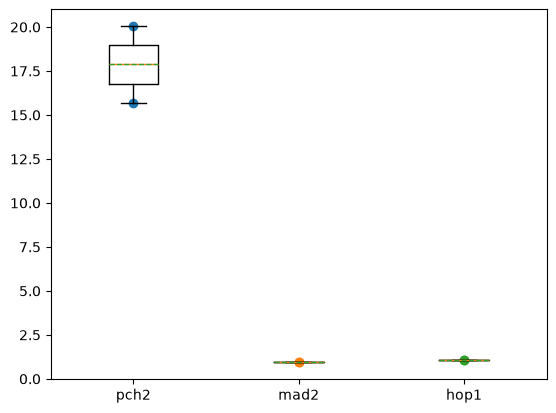

In [329]:
graph_organism(shared_datasets, org, 'DS_14b0e873fb', save=False, filter_words=["antisense", "wheat"])

In [326]:
# Plot all the data with scatters and boxplots and save them as PNGs

import matplotlib.pyplot as plt
from pathlib import Path


def graph_organism(shared_datasets, organism, dataset_selector=None, save=True, filter_words=["antisense"]):

    first_shared_dataset = {}
    first_shared_dataset[organism] = select_dataset(shared_datasets[organism], dataset_selector)

    dataset = first_shared_dataset[organism][~first_shared_dataset[organism]["sample_name"].str.contains("|".join(filter_words),case=False,na=False)]
    pch2_data = dataset[dataset["protein"]=="pch2"]
    mad2_data = dataset[dataset["protein"]=="mad2"]
    hop1_data = dataset[dataset["protein"]=="hop1"]

    pch2_data_numeric = pd.to_numeric(pch2_data["value"])
    mad2_data_numeric = pd.to_numeric(mad2_data["value"])
    hop1_data_numeric = pd.to_numeric(hop1_data["value"])

    plt.boxplot([pch2_data_numeric, mad2_data_numeric, hop1_data_numeric], positions=[0,1,2], showmeans=True, meanline=True)
    plt.scatter([0]*len(pch2_data), pch2_data_numeric)
    plt.scatter([1]*len(mad2_data), mad2_data_numeric)
    plt.scatter([2]*len(hop1_data), hop1_data_numeric)

    plt.xticks([0, 1, 2], ["pch2", "mad2", "hop1"])
    plt.title = organism
    if save:
        output_dir = Path("RNAseq_figures")
        output_dir.mkdir(exist_ok=True)

        filename = organism.replace("/", "_")
        plt.savefig(output_dir / f"{filename}.png", bbox_inches="tight")
        plt.close()
    else:
        plt.show()
    
    return

for organism in organisms_with_all_data:
    graph_organism(shared_datasets, organism, dataset_selector[organism])
    # dataset = first_shared_dataset[organism][~first_shared_dataset[organism]["sample_name"].str.contains("antisense")]
    # pch2_data = dataset[dataset["protein"]=="pch2"]
    # mad2_data = dataset[dataset["protein"]=="mad2"]
    # hop1_data = dataset[dataset["protein"]=="hop1"]

    # pch2_data_numeric = pd.to_numeric(pch2_data["value"])
    # mad2_data_numeric = pd.to_numeric(mad2_data["value"])
    # hop1_data_numeric = pd.to_numeric(hop1_data["value"])

    # plt.boxplot([pch2_data_numeric, mad2_data_numeric, hop1_data_numeric], positions=[0,1,2], showmeans=True, meanline=True)
    # plt.scatter([0]*len(pch2_data), pch2_data_numeric)
    # plt.scatter([1]*len(mad2_data), mad2_data_numeric)
    # plt.scatter([2]*len(hop1_data), hop1_data_numeric)

    # plt.xticks([0, 1, 2], ["pch2", "mad2", "hop1"])
    # plt.title = organism
    # filename = organism.replace("/", "_")
    # plt.savefig(output_dir / f"{filename}.png", bbox_inches="tight")
    # plt.close()




**Random Test Below**

In [196]:
# dataset = first_shared_dataset["Cryptococcus neoformans var. grubii H99"]
# dataset = first_shared_dataset["Cryptococcus neoformans var. neoformans JEC21"]
# dataset = first_shared_dataset["Saccharomyces cerevisiae S288C"]

orgo = "Cryptococcus neoformans var. neoformans JEC21"
dataset = first_shared_dataset[orgo][~first_shared_dataset[orgo]["sample_name"].str.contains("antisense")]
pch2_data = dataset[dataset["protein"]=="pch2"]
mad2_data = dataset[dataset["protein"]=="mad2"]
hop1_data = dataset[dataset["protein"]=="hop1"]

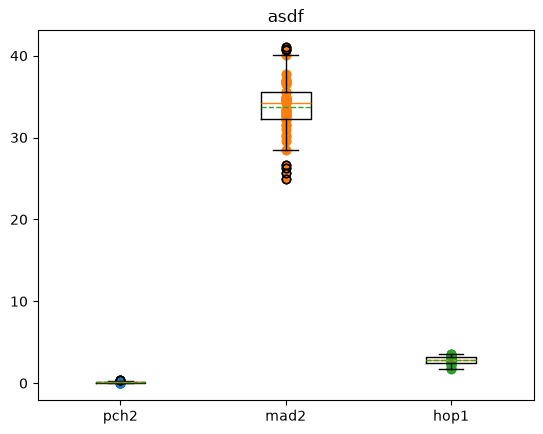

In [194]:
pch2_data_numeric = pd.to_numeric(pch2_data["value"])
mad2_data_numeric = pd.to_numeric(mad2_data["value"])
hop1_data_numeric = pd.to_numeric(hop1_data["value"])


plt.boxplot([pch2_data_numeric, mad2_data_numeric, hop1_data_numeric], positions=[0,1,2], showmeans=True, meanline=True)
plt.scatter([0]*len(pch2_data), pch2_data_numeric)
plt.scatter([1]*len(mad2_data), mad2_data_numeric)
plt.scatter([2]*len(hop1_data), hop1_data_numeric)

plt.xticks([0, 1, 2], ["pch2", "mad2", "hop1"])
plt.title("asdf")
plt.show()

In [ ]:
%connect_info